# Finals Utility Functions
Generalized helper functions based on tutorial code. Just plug in your matrices and run.

In [2]:
import numpy as np
from numpy.linalg import inv, det
from scipy import stats
from sklearn.preprocessing import PolynomialFeatures, OneHotEncoder
from sklearn.metrics import mean_squared_error
import matplotlib.pyplot as plt
from math import exp, sqrt, sin, cos
from math import factorial as fac
from math import log as ln


---
## 1. Matrix Properties

In [14]:
def matrix_info(A):
    """
    Prints key properties of a matrix A:
    shape, rank, determinant (if square), transpose, and invertibility.
    """
    A = np.array(A, dtype=float)
    m, n = A.shape
    print("A =\n", A)
    print("Shape:", A.shape)
    print("Rank:", np.linalg.matrix_rank(A))
    print("Transpose A^T =\n", A.T)

    if m == n:
        d = det(A)
        print("det(A) =", d)
        if abs(d) > 1e-10:
            adj = d * inv(A)          # adj(A) = det(A) * A^{-1}
            print("adj(A) =\n", adj)
            print("inv(A) =\n", inv(A))
        else:
            print("Matrix is SINGULAR — inverse does not exist.")
    else:
        print("Non-square matrix — checking pseudo-inverses:")
        left_ok  = abs(det(A.T @ A)) > 1e-10
        right_ok = abs(det(A @ A.T)) > 1e-10
        print(f"  Left inverse  (A^T A invertible): {left_ok}")
        print(f"  Right inverse (A A^T invertible): {right_ok}")

# ── USAGE ────────────────────────────────────────────
A = [[1,2],[0,1],[2,3]]
matrix_info(A)

A =
 [[1. 2.]
 [0. 1.]
 [2. 3.]]
Shape: (3, 2)
Rank: 2
Transpose A^T =
 [[1. 0. 2.]
 [2. 1. 3.]]
Non-square matrix — checking pseudo-inverses:
  Left inverse  (A^T A invertible): True
  Right inverse (A A^T invertible): False


---
## 2. Solving Linear Systems  Ax = b

In [ ]:
def solve_system(A, b):
    """
    Solves Ax = b, choosing the right method automatically:
      - Square & invertible  → exact solution  x = A^{-1} b
      - Overdetermined (m>n) → least squares   x = (A^T A)^{-1} A^T b
      - Underdetermined(m<n) → minimum norm    x = A^T (A A^T)^{-1} b
    """
    A = np.array(A, dtype=float)
    b = np.array(b, dtype=float)
    m, n = A.shape

    if m == n:
        d = det(A)
        if abs(d) < 1e-10:
            print("Singular matrix — no unique solution.")
            return None
        x = inv(A) @ b
        print("Square system → exact solution")
    elif m > n:
        x = inv(A.T @ A) @ A.T @ b
        print("Overdetermined (m>n) → least squares solution")
    else:
        x = A.T @ inv(A @ A.T) @ b
        print("Underdetermined (m<n) → minimum norm solution")

    print("x =\n", x)
    return x

# ── USAGE ────────────────────────────────────────────
A = [[1,1],[3,4]]
b = [[0],[1]]
solve_system(A, b)

---
## 3. Linear Regression (with / without bias)

In [5]:
import numpy as np
from numpy.linalg import inv

def linear_regression(X_raw, y, bias=True, l2_lambda=0.0):
    """
    Fits a linear regression model (with optional L2 regularization)
    and returns weights and a prediction function.
    """
    X_raw = np.array(X_raw, dtype=float)
    y     = np.array(y, dtype=float)

    # 1. Prepare training data
    X = np.c_[np.ones(X_raw.shape[0]), X_raw] if bias else X_raw
    m, d = X.shape

    # 2. Solve for weights w with L2 Regularization
    # Formula: w = inv(X.T @ X + lambda * I) @ X.T @ y

    # Create Identity matrix I
    I = np.eye(d)

    # Usually, we don't regularize the bias term (the first column)
    if bias and l2_lambda > 0:
        I[0, 0] = 0

    # Solve using the regularized normal equation
    # This form works for overdetermined, underdetermined, and square cases
    w = inv(X.T @ X + l2_lambda * I) @ X.T @ y

    # 3. Define the prediction sub-function
    def predict(X_new):
        X_new = np.array(X_new, dtype=float)
        if X_new.ndim == 1:
            X_new = X_new.reshape(1, -1)

        X_predict = np.c_[np.ones(X_new.shape[0]), X_new] if bias else X_new
        return X_predict @ w

    y_pred_train = X @ w
    mse_train = np.mean((y_pred_train - y)**2)

    print(f"Model trained (L2={l2_lambda}). MSE: {mse_train:.6f}")

    return w, predict

# ── USAGE ────────────────────────────────────────────
X_raw = [[1, 2], [3, 4], [4, -1]]
y     = [[1, 2], [3, 1], [2, 3]]

# To "turn off" regularization, keep l2_lambda=0.0
# To "turn on", provide a positive float (e.g., 0.1)
w, predict = linear_regression(X_raw, y, bias=False, l2_lambda=0.5)

new_x = [1, 3]
prediction = predict(new_x)

print("Weights (w):\n", w)
print("\nNew Input:", new_x)
print("Predicted y:", prediction)

Model trained (L2=0.5). MSE: 0.465284
Weights (w):
 [[ 0.56838744  0.67163385]
 [ 0.29377328 -0.0798297 ]]

New Input: [1, 3]
Predicted y: [[1.44970729 0.43214476]]


---
## 4. Polynomial Regression

In [17]:
def poly_regression(X_raw, y, degree=2, lam=0.0, plot=True):
    """
    Fits a polynomial regression model and returns weights and a prediction function.
    """
    X_raw = np.array(X_raw, dtype=float)
    y     = np.array(y, dtype=float)

    # 1. Transform features to polynomial space
    poly = PolynomialFeatures(degree=degree)
    P    = poly.fit_transform(X_raw)
    print(P)
    m, d = P.shape

    # 2. Solve for weights w (Primal vs Dual with L2 Regularization)
    if m >= d:
        # Primal form: (P^T P + λI)^-1 P^T y
        w = inv(P.T @ P + lam * np.eye(d)) @ P.T @ y
    else:
        # Dual form (useful when features > samples): P^T (P P^T + λI)^-1 y
        w = P.T @ inv(P @ P.T + lam * np.eye(m)) @ y

    # 3. Define the prediction sub-function
    def predict(X_new):
        X_new = np.array(X_new, dtype=float)
        # Reshape if it's a single sample (e.g., [5] instead of [[5]])
        if X_new.ndim == 1 and X_raw.shape[1] == 1:
            X_new = X_new.reshape(-1, 1)
        elif X_new.ndim == 1:
            X_new = X_new.reshape(1, -1)

        # MUST transform the new X using the same poly object
        P_new = poly.transform(X_new)
        return P_new @ w

    # 4. Optional Plotting
    if plot and X_raw.shape[1] == 1:
        x_line = np.linspace(X_raw.min()-1, X_raw.max()+1, 200).reshape(-1,1)
        y_line = predict(x_line) # Using our new predict function!
        plt.figure(figsize=(8,4))
        plt.scatter(X_raw, y, color='black', label='Training data')
        plt.plot(x_line, y_line, color='red', label=f'Degree {degree}, λ={lam}')
        plt.legend(); plt.grid(True, linestyle=':'); plt.show()

    return w, predict

# ── USAGE ────────────────────────────────────────────
X_raw = [[1,1],[2,1],[1,2],[2,3]]
y     = [[2],[3.1],[3.5],[4]]

# Train the model and get the predict function
w, predict = poly_regression(X_raw, y, degree=1, lam=0, plot=False)

# Now predict a brand new value
val = [10,10]
prediction = predict(val)

print(f"Weights: w=\n{np.array2string(w, precision=4, suppress_small=True)}")
print(f"Prediction for x={val}: {prediction[0][0]:.4f}") #Change the decimal point as per question

[[1. 1. 1.]
 [1. 2. 1.]
 [1. 1. 2.]
 [1. 2. 3.]]
Weights: w=
[[1.29]
 [0.47]
 [0.66]]
Prediction for x=[10, 10]: 12.5900


---
## 5. MSE vs Polynomial Degree (with / without regularization)

[[1.29]
 [0.47]
 [0.66]]
Degree 1: Train MSE=0.1102  Test MSE=0.0676


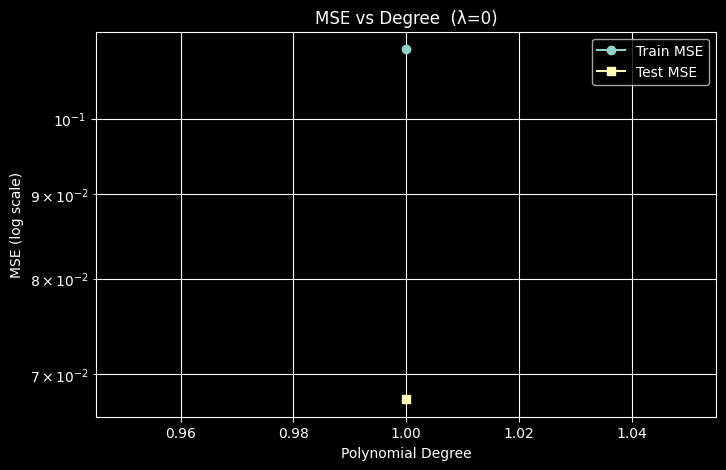

([np.float64(0.11024999999999996)], [np.float64(0.06760000000000174)])

In [18]:
def mse_vs_degree(X_tr, y_tr, X_ts, y_ts, max_degree=6, lam=0.0):
    """
    Trains polynomial models from degree 1 to max_degree.
    Plots and returns train/test MSE lists.
    """
    X_tr = np.array(X_tr, dtype=float)
    y_tr = np.array(y_tr, dtype=float)
    X_ts = np.array(X_ts, dtype=float)
    y_ts = np.array(y_ts, dtype=float)

    mse_train_list, mse_test_list = [], []
    degrees = list(range(1, max_degree+1))

    for deg in degrees:
        poly  = PolynomialFeatures(degree=deg)
        P_tr  = poly.fit_transform(X_tr)
        P_ts  = poly.transform(X_ts)
        m, d  = P_tr.shape

        I = np.eye(d)
        if m >= d:
            w = inv(P_tr.T @ P_tr + lam * I) @ P_tr.T @ y_tr
        else:
            w = P_tr.T @ inv(P_tr @ P_tr.T + lam * np.eye(m)) @ y_tr
        print(w)
        mse_train = np.mean((P_tr @ w - y_tr)**2)
        mse_test  = np.mean((P_ts @ w - y_ts)**2)
        mse_train_list.append(mse_train)
        mse_test_list.append(mse_test)
        print(f"Degree {deg}: Train MSE={mse_train:.4f}  Test MSE={mse_test:.4f}")

    plt.figure(figsize=(8,5))
    plt.plot(degrees, mse_train_list, 'o-', label='Train MSE')
    plt.plot(degrees, mse_test_list,  's-', label='Test MSE')
    plt.yscale('log')
    plt.xlabel('Polynomial Degree')
    plt.ylabel('MSE (log scale)')
    plt.title(f'MSE vs Degree  (λ={lam})')
    plt.legend(); plt.grid(True, which='both'); plt.show()

    return mse_train_list, mse_test_list

# ── USAGE ────────────────────────────────────────────
X_tr = [[1,1],[2,1],[1,2],[2,3]]
y_tr = [[2],[3.1],[3.5],[4]]
X_ts = [[1,3]]
y_ts = [[4]]
mse_vs_degree(X_tr, y_tr, X_ts, y_ts, max_degree=1, lam=0)

---
## 6. Binary Classification (Linear / Polynomial)

In [8]:
def binary_classify(X_raw, y, X_test, degree=1, lam=0.0):
    """
    Binary classifier using linear regression + sign().
    y must contain +1 / -1 labels.
    degree=1 → linear (adds bias automatically)
    degree>1 → polynomial features
    """
    X_raw  = np.array(X_raw, dtype=float)
    y      = np.array(y, dtype=float)
    X_test = np.array(X_test, dtype=float)

    poly = PolynomialFeatures(degree=degree)
    P    = poly.fit_transform(X_raw)
    Pt   = poly.transform(X_test)
    m, d = P.shape

    I = np.eye(d)
    if m >= d:
        w = inv(P.T @ P + lam * I) @ P.T @ y
        print(f"Degree {degree} — overdetermined")
    else:
        w = P.T @ inv(P @ P.T + lam * np.eye(m)) @ y
        print(f"Degree {degree} — underdetermined (least norm)")

    print("Weights w =\n", w)
    y_raw  = Pt @ w
    y_pred = np.sign(y_raw)
    print("Raw output =\n", y_raw)
    print("Predicted classes (+1/-1) =\n", y_pred)
    return w, poly, y_pred

# ── USAGE ────────────────────────────────────────────
X_raw  = [[4],[7],[10],[2],[3],[9]]
y      = [[-1],[-1],[-1],[1],[1],[1]]
X_test = [[4],[7],[10],[2],[3],[9],[6]]
binary_classify(X_raw, y, X_test, degree=4)

Degree 4 — overdetermined
Weights w =
 [[-11.21971831]
 [ 13.52136821]
 [ -4.88054326]
 [  0.65537223]
 [ -0.02923541]]
Raw output =
 [[-0.76338028]
 [-1.11830986]
 [-1.04225352]
 [ 1.07605634]
 [ 0.74647887]
 [ 1.10140845]
 [-2.11975855]]
Predicted classes (+1/-1) =
 [[-1.]
 [-1.]
 [-1.]
 [ 1.]
 [ 1.]
 [ 1.]
 [-1.]]


(array([[-11.21971831],
        [ 13.52136821],
        [ -4.88054326],
        [  0.65537223],
        [ -0.02923541]]),
 PolynomialFeatures(degree=4),
 array([[-1.],
        [-1.],
        [-1.],
        [ 1.],
        [ 1.],
        [ 1.],
        [-1.]]))

---
## 7. Multi-Class Classification (One-Hot Encoding)

In [24]:
def multi_class_classify(X_raw, y_labels, X_test, degree=1, lam=0.0):
    """
    Multi-class classifier using one-hot encoding + linear/polynomial regression.
    y_labels: list of class label strings or integers, shape (m,1) or (m,)
    Returns predicted class labels for X_test.
    """
    X_raw    = np.array(X_raw, dtype=float)
    X_test   = np.array(X_test, dtype=float)
    y_labels = np.array(y_labels).reshape(-1,1)

    enc         = OneHotEncoder(sparse_output=False)
    y_onehot    = enc.fit_transform(y_labels)

    poly = PolynomialFeatures(degree=degree)
    P    = poly.fit_transform(X_raw)
    Pt   = poly.transform(X_test)
    m, d = P.shape
    print(P)

    I = np.eye(d)
    if m >= d:
        w = inv(P.T @ P + lam * I) @ P.T @ y_onehot
        print(f"Degree {degree} — overdetermined")
    else:
        w = P.T @ inv(P @ P.T + lam * np.eye(m)) @ y_onehot
        print(f"Degree {degree} — underdetermined (least norm)")

    print(f" Weights\n: {w}")

    y_raw  = Pt @ w
    print("Raw scores =\n", y_raw)

    pred_idx    = np.argmax(y_raw, axis=1)
    pred_labels = enc.categories_[0][pred_idx]
    print("Predicted labels:", pred_labels)
    return w, enc, pred_labels

# ── USAGE ────────────────────────────────────────────
X_raw    = [[2,1,0],[0,3,1],[1,0,3],[3,1,4],[-1,2,1]]
y_labels = [["class1"],["class3"],["class2"],["class1"],["class2"]]
X_test   = [[1,1,2]]
multi_class_classify(X_raw, y_labels, X_test, degree=2, lam=0.01)

[[ 1.  2.  1.  0.  4.  2.  0.  1.  0.  0.]
 [ 1.  0.  3.  1.  0.  0.  0.  9.  3.  1.]
 [ 1.  1.  0.  3.  1.  0.  3.  0.  0.  9.]
 [ 1.  3.  1.  4.  9.  3. 12.  1.  4. 16.]
 [ 1. -1.  2.  1.  1. -2. -1.  4.  2.  1.]]
Degree 2 — underdetermined (least norm)
 Weights
: [[ 4.76806275e-02  1.10923433e-01 -1.90845784e-02]
 [ 8.11406706e-02 -5.46980732e-02  5.27998448e-02]
 [ 3.08346840e-02  6.30150992e-02 -6.35785320e-03]
 [-1.06517500e-04  1.06275583e-01 -9.45721518e-03]
 [ 1.56381995e-01  9.91252697e-02 -1.03747363e-01]
 [ 6.81532775e-02 -2.06465533e-01  1.06631265e-01]
 [-4.45019947e-02 -2.18761784e-01  4.21775047e-02]
 [-3.10423990e-03 -4.84514555e-02  1.21605193e-01]
 [-3.17456109e-02 -3.36457041e-02 -1.47062151e-02]
 [-1.68279692e-02  1.31294212e-01 -3.13540566e-03]]
Raw scores =
 [[0.16106689 0.19636178 0.17533303]]
Predicted labels: ['class2']


(array([[ 4.76806275e-02,  1.10923433e-01, -1.90845784e-02],
        [ 8.11406706e-02, -5.46980732e-02,  5.27998448e-02],
        [ 3.08346840e-02,  6.30150992e-02, -6.35785320e-03],
        [-1.06517500e-04,  1.06275583e-01, -9.45721518e-03],
        [ 1.56381995e-01,  9.91252697e-02, -1.03747363e-01],
        [ 6.81532775e-02, -2.06465533e-01,  1.06631265e-01],
        [-4.45019947e-02, -2.18761784e-01,  4.21775047e-02],
        [-3.10423990e-03, -4.84514555e-02,  1.21605193e-01],
        [-3.17456109e-02, -3.36457041e-02, -1.47062151e-02],
        [-1.68279692e-02,  1.31294212e-01, -3.13540566e-03]]),
 OneHotEncoder(sparse_output=False),
 array(['class2'], dtype='<U6'))

---
## 8. Pearson Correlation

In [6]:
def pearson_correlation(features_dict, target):
    """
    Computes Pearson correlation between each feature and the target.
    features_dict: {'feature_name': [values], ...}
    target       : list of target values
    """
    print(f"{'Feature':<15} {'r':>8} {'p-value':>12}")
    print("-" * 38)
    for name, feat in features_dict.items():
        r, p = stats.pearsonr(feat, target)
        print(f"{name:<15} {r:>8.4f} {p:>12.4f}")

# ── USAGE ────────────────────────────────────────────
features = {
    'feature1': [3,7,5,8,4],
    'feature2': [8,2,6,1,7],
    'feature3': [3,2,10,5,4],
    'feature4': [7,4,2,6,5],
    'feature5': [2,8,5,7,3]
}
target_y = [21,48,64,82,30]
pearson_correlation(features, target_y)

Feature                r      p-value
--------------------------------------
feature1          0.8362       0.0776
feature2         -0.7639       0.1327
feature3          0.4952       0.3963
feature4         -0.3511       0.5623
feature5          0.7315       0.1601


---
## 9. Normal Distribution Probabilities

In [ ]:
def normal_prob(mu, sigma, lower=None, upper=None, plot=True):
    """
    Computes P[lower < X < upper] for X ~ N(mu, sigma^2).
    Leave lower=None for P[X < upper], upper=None for P[X > lower].
    """
    if lower is None and upper is None:
        print("Provide at least one of lower / upper."); return

    if lower is None:
        prob = stats.norm.cdf(upper, mu, sigma)
        print(f"P[X < {upper}] = {prob:.6f}")
    elif upper is None:
        prob = 1 - stats.norm.cdf(lower, mu, sigma)
        print(f"P[X > {lower}] = {prob:.6f}")
    else:
        prob = stats.norm.cdf(upper, mu, sigma) - stats.norm.cdf(lower, mu, sigma)
        print(f"P[{lower} < X < {upper}] = {prob:.6f}")

    if plot:
        x = np.linspace(mu - 4*sigma, mu + 4*sigma, 300)
        y = stats.norm.pdf(x, mu, sigma)
        plt.figure(figsize=(8,4))
        plt.plot(x, y, label=f'N({mu}, {sigma}²)')
        lo = lower if lower is not None else mu - 4*sigma
        hi = upper if upper is not None else mu + 4*sigma
        mask = (x >= lo) & (x <= hi)
        plt.fill_between(x, y, where=mask, alpha=0.4, label=f'prob={prob:.4f}')
        plt.title("Normal Distribution")
        plt.legend(); plt.grid(True, linestyle=':'); plt.show()

    return prob

# ── USAGE ────────────────────────────────────────────
normal_prob(mu=30, sigma=1.8, lower=28, upper=33)

---
## 10. Ridge Regression (L2 Regularization) — Primal & Dual

w (primal) =
 [[ 0.73180897]
 [ 0.31710254]
 [ 0.19574766]
 [ 0.13807518]
 [-0.06978797]
 [ 0.0080701 ]]
w (dual)   =
 [[ 0.73180897]
 [ 0.31710254]
 [ 0.19574766]
 [ 0.13807518]
 [-0.06978797]
 [ 0.0080701 ]]
Max difference primal vs dual: 1.2124412585023947e-11


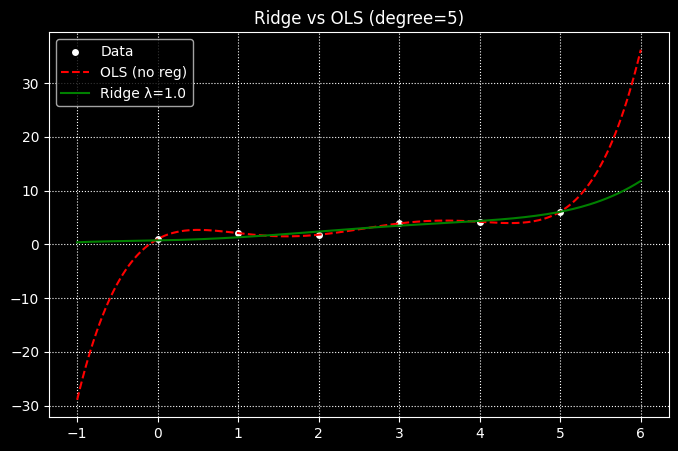

array([[ 0.73180897],
       [ 0.31710254],
       [ 0.19574766],
       [ 0.13807518],
       [-0.06978797],
       [ 0.0080701 ]])

In [19]:
def ridge_regression(X_raw, y, degree=1, lam=1.0, X_test=None, plot=True):
    """
    Ridge regression using both primal and dual form.
    Verifies both forms give the same answer.
    """
    X_raw = np.array(X_raw, dtype=float)
    y     = np.array(y, dtype=float)

    poly = PolynomialFeatures(degree=degree)
    P    = poly.fit_transform(X_raw)
    m, d = P.shape

    I_primal = np.eye(d)
    I_dual   = np.eye(m)

    w_primal = inv(P.T @ P + lam * I_primal) @ P.T @ y
    w_dual   = P.T @ inv(P @ P.T + lam * I_dual) @ y

    print("w (primal) =\n", w_primal)
    print("w (dual)   =\n", w_dual)
    print("Max difference primal vs dual:", np.max(np.abs(w_primal - w_dual)))

    if X_test is not None:
        X_test = np.array(X_test, dtype=float)
        Pt     = poly.transform(X_test)
        y_test = Pt @ w_primal
        print("Test predictions =\n", y_test)

    if plot and X_raw.shape[1] == 1:
        x_line = np.linspace(X_raw.min()-1, X_raw.max()+1, 200).reshape(-1,1)
        y_line = poly.transform(x_line) @ w_primal
        w_ols  = inv(P.T @ P) @ P.T @ y
        y_ols  = poly.transform(x_line) @ w_ols
        plt.figure(figsize=(8,5))
        plt.scatter(X_raw, y, color='white', edgecolors='black', label='Data')
        plt.plot(x_line, y_ols,   'r--', label=f'OLS (no reg)')
        plt.plot(x_line, y_line,  'g-',  label=f'Ridge λ={lam}')
        plt.title(f'Ridge vs OLS (degree={degree})')
        plt.legend(); plt.grid(True, linestyle=':'); plt.show()

    return w_primal

# ── USAGE ────────────────────────────────────────────
X_raw = [[1,2],[3,4],[4,-1]]
y     = [[1,2],[3,1],[2,3]]
ridge_regression(X_raw, y, degree=1, lam=1.0)

---
## 11. Quick Check: Invertibility & Pseudo-Inverses

In [ ]:
def check_invertibility(A):
    """
    For any matrix A, reports:
    - Is it square invertible?
    - Does left inverse (A^T A)^{-1} A^T exist?
    - Does right inverse A^T (A A^T)^{-1} exist?
    """
    A = np.array(A, dtype=float)
    m, n = A.shape
    print("Shape:", A.shape, "  Rank:", np.linalg.matrix_rank(A))

    if m == n:
        d = det(A)
        print(f"Square matrix: det={d:.4f}  → invertible: {abs(d)>1e-10}")

    d_left  = det(A.T @ A)
    d_right = det(A @ A.T)
    print(f"det(A^T A)={d_left:.4f}  → left inverse exists:  {abs(d_left)>1e-10}")
    print(f"det(A A^T)={d_right:.4f} → right inverse exists: {abs(d_right)>1e-10}")

# ── USAGE ────────────────────────────────────────────
A = [[2,0,0],[0,0,1]]
check_invertibility(A)

## 12. Polynomial Regression and Regularization with MSE


In [3]:
def poly_regression_MSE(X_raw, y, degree=2, lam=0.0):
    X_raw = np.array(X_raw, dtype=float)
    y     = np.array(y, dtype=float)

    poly = PolynomialFeatures(degree=degree)
    P    = poly.fit_transform(X_raw)
    m, d = P.shape

    # Solve for weights w
    if m >= d:
        w = inv(P.T @ P + lam * np.eye(d)) @ P.T @ y
    else:
        w = P.T @ inv(P @ P.T + lam * np.eye(m)) @ y

    # Calculate Training MSE
    y_pred_train = P @ w
    mse_train = np.mean((y_pred_train - y)**2)

    # --- Generate the equation string ---
    feature_names = poly.get_feature_names_out()
    w_flat = w.flatten()
    terms = []
    for i, name in enumerate(feature_names):
        weight = w_flat[i]
        if abs(weight) < 1e-10: continue # Skip near-zero weights
        if name == "1":
            terms.append(f"{weight:.4f}")
        else:
            # Replace 'x0' with 'x0', 'x1' with 'x1', etc.
            terms.append(f"({weight:.4f} * {name})")
    equation_str = "y = " + " + ".join(terms)

    def predict(X_new):
        X_new = np.array(X_new, dtype=float)
        if X_new.ndim == 1:
            X_new = X_new.reshape(-1, 1 if X_raw.shape[1] == 1 else X_raw.shape[1])
        P_new = poly.transform(X_new)
        return P_new @ w

    return w, predict, mse_train, equation_str

# ── USAGE ────────────────────────────────────────────
X_raw = [[-2],[1],[5]]
#y_true_train = [[6], [5], [8],[4],[7]]
y_true_train = [[3],[5],[6]] #can handle single output only

# 1. Train the model
w, predict, mse, equation = poly_regression_MSE(X_raw, y_true_train, degree=1, lam=0.5) #remeber to turn off lambda

# 2. Predict a new value and compare with an actual ground truth
val = [1]
y_actual_new = 3  # Assume we know the actual value for this point
prediction = predict(val)[0][0]

# 3. Calculate the specific error for this point
point_error = abs(prediction - y_actual_new)

print(f"Weights: w=\n{np.array2string(w, precision=3, suppress_small=True)}")
print(f"Training MSE: {mse:.3f}")
print(f"Equation: {equation}") # Output the equation
print("-" * 30)
print(f"Prediction for x={val}: {prediction:.3f}")
print(f"Actual value: {y_actual_new:.3f}")
print(f"Absolute Error for this point: {point_error:.3f}")

Weights: w=
[[3.427]
 [0.501]]
Training MSE: 0.495
Equation: y = 3.4270 + (0.5014 * x0)
------------------------------
Prediction for x=[1]: 3.928
Actual value: 3.000
Absolute Error for this point: 0.928


In [31]:
import numpy as np
from numpy.linalg import inv
from sklearn.preprocessing import PolynomialFeatures

def poly_model_smart(X_raw, y_raw, degree=1, lam=0.0, mode='regression', bias=True):
    X_raw = np.array(X_raw, dtype=float)

    # --- 1. Handle Labels ---
    is_classifier = (mode.lower() == 'classification')
    label_map = None
    inv_label_map = None

    if is_classifier:
        unique_labels = sorted(list(set(y_raw)))
        label_map = {label: i for i, label in enumerate(unique_labels)}
        inv_label_map = {i: label for label, i in label_map.items()}
        num_classes = len(unique_labels)

        y = np.zeros((len(y_raw), num_classes))
        for i, label in enumerate(y_raw):
            y[i, label_map[label]] = 1.0
    else:
        y = np.array(y_raw, dtype=float)
        if y.ndim == 1: y = y.reshape(-1, 1)

    # Check for dimension mismatch
    if X_raw.shape[0] != y.shape[0]:
        raise ValueError(f"Data length mismatch! X has {X_raw.shape[0]} rows, but y has {y.shape[0]} rows.")

    # --- 2. Training Logic ---
    poly = PolynomialFeatures(degree=degree, include_bias=bias)
    P = poly.fit_transform(X_raw)
    m, d = P.shape
    k = y.shape[1]

    # Normal Equation
    if m >= d:
        w = inv(P.T @ P + lam * np.eye(d)) @ P.T @ y
    else:
        w = P.T @ inv(P @ P.T + lam * np.eye(m)) @ y

    # --- 3. Generate Equations ---
    feature_names = poly.get_feature_names_out()
    equations = []
    for target_idx in range(k):
        w_target = w[:, target_idx]
        terms = []
        for i, name in enumerate(feature_names):
            weight = w_target[i]
            if abs(weight) < 1e-10: continue
            if name == "1": terms.append(f"{weight:.4f}")
            else: terms.append(f"({weight:.4f} * {name})")

        prefix = f"Class '{inv_label_map[target_idx]}'" if is_classifier else f"Target {target_idx}"
        equations.append(f"{prefix}: y = " + " + ".join(terms))

    # --- 4. Prediction Sub-function ---
    def predict(X_new, return_raw=False):
        X_new = np.array(X_new, dtype=float)
        if X_new.ndim == 1: X_new = X_new.reshape(1, -1)
        P_new = poly.transform(X_new)
        raw_output = P_new @ w

        if is_classifier and not return_raw:
            indices = np.argmax(raw_output, axis=1)
            return [inv_label_map[i] for i in indices]
        return raw_output

    # --- 5. Calculate Performance ---
    y_pred_train = predict(X_raw)
    if is_classifier:
        accuracy = np.mean(np.array(y_pred_train) == np.array(y_raw))
        return w, predict, accuracy, "Accuracy", equations
    else:
        mse = np.mean((y_pred_train - y)**2)
        return w, predict, mse, "MSE", equations

# ── FIXED USAGE ──────────────────────────────────────

# X needs 5 samples to match y_data
X_data = [
    [3,8,2],
    [7,2,8],
    [5,6,5],
    [8,1,7],
    [4,7,3]
]

# y_data has 5 samples, each with 3 targets
y_data = [
    [30,21],
    [92,48],
    [67,64],
    [105,82],
    [41,30]
]

print("--- REGRESSION ---")
w, pred, mse, name, eqs = poly_model_smart(X_data, y_data, degree=2, bias=True, lam=0.1)

print(f"Overall {name}: {mse:.6f}")
print("\nEquations:")
for eq in eqs:
    print(eq)

print("-" * 30)
test_point = [9,4,5]
prediction = pred(test_point)
print(f"Prediction for {test_point}: {prediction}")

# ── USAGE: MULTI-CLASS CLASSIFICATION ────────────────
print("--- CLASSIFICATION ---")
# Features: [Weight in grams, Texture (1=Smooth, 10=Rough)]
X_class = [
    [1,3,-2],
    [-4,0,-1],
    [3,1,8],
    [2,1,6],
    [8,4,6]
]

# Labels as strings (The code handles the conversion)
y_class = [
    "class1",
    "class1",
    "class2",
    "class3",
    "class3"
]

# 1. Train the model
# degree=1 is usually enough for simple linear separation
# lam=0.1 adds a bit of regularization to prevent overfitting
w, predict, accuracy, name, eqs = poly_model_smart(
    X_class,
    y_class,
    degree=1,
    lam=0.00,
    mode='classification',
    bias=True
)

# 2. Output training results
print(f"Training {name}: {accuracy:.2%}")
print("\nDecision Equations (One per class):")
for eq in eqs:
    print(eq)

print("-" * 40)

# 3. Predict for new, unseen data
test_samples = [
    [1,3,-2],   # Should be Apple
    [-4,0,1],    # Should be Strawberry
    [3,1,8],   # Should be Watermelon
    [2,1,6],
    [8,4,6],
    [1,-2,4]
]

predictions = predict(test_samples)

for x, label in zip(test_samples, predictions):
    print(f"Input {x} => Predicted Category: {label}")

--- REGRESSION ---
Overall MSE: 0.024036

Equations:
Target 0: y = -0.0445 + (-0.1142 * x0) + (-0.1599 * x1) + (0.0515 * x2) + (1.1810 * x0^2) + (-1.2747 * x0 x1) + (0.7825 * x0 x2) + (0.2899 * x1^2) + (1.8496 * x1 x2) + (-0.3409 * x2^2)
Target 1: y = -0.1847 + (-0.6592 * x0) + (-0.6227 * x1) + (-0.0207 * x2) + (1.8504 * x0^2) + (-4.9065 * x0 x1) + (1.1638 * x0 x2) + (0.6148 * x1^2) + (5.6672 * x1 x2) + (-1.9685 * x2^2)
------------------------------
Prediction for [9, 4, 5]: [[116.63880591  90.87239562]]
--- CLASSIFICATION ---
Training Accuracy: 100.00%

Decision Equations (One per class):
Class 'class1': y = -0.0101 + (-0.2487 * x0) + (0.4472 * x1) + (0.0302 * x2)
Class 'class2': y = -6.0302 + (-1.7462 * x0) + (3.3417 * x1) + (1.0905 * x2)
Class 'class3': y = 7.0402 + (1.9950 * x0) + (-3.7889 * x1) + (-1.1206 * x2)
----------------------------------------
Input [1, 3, -2] => Predicted Category: class1
Input [-4, 0, 1] => Predicted Category: class2
Input [3, 1, 8] => Predicted Categor

## 13. Pearson's Correlation


In [50]:
def pearson_correlation(x, y):
    """
    Returns Pearson r between two lists / arrays.
    Usage:
        r = pearson_correlation(feature1, target_y)
    """
    x, y = np.array(x, dtype=float), np.array(y, dtype=float)
    diff_x = x - x.mean()
    diff_y = y - y.mean()
    return np.dot(diff_x, diff_y) / (np.sqrt(np.sum(diff_x**2) * np.sum(diff_y**2)))


def pearson_all_features(features_dict, target_y):
    """
    Prints Pearson r for every feature vs target.
    Usage:
        features = {"feature1": [0.35, 2.18, ...], "feature2": [...]}
        pearson_all_features(features, target_y)
    """
    target_y = np.array(target_y, dtype=float)
    print("=== Pearson Correlation ===")
    for name, vals in features_dict.items():
        r = pearson_correlation(vals, target_y)
        print(f"  {name:20s}  r = {r:.6f}")


# ─── EXAMPLE (replace with your data) ─────────────────────────
if __name__ == "__main__":
    feature1 = [3.3459, 1.0893, 3.2103, 1.744, 1.6762]
    feature2 = [27435, 2.9113, 1.4706, 1.2895, 2.1366]
    feature3 = [-1.7253, -0.7804, -0.9944, 0.5307, -1.0502]
    target_y  = [2.9972, 1.1399, 2.228, 0.3387, 2.5042]

    pearson_all_features(
        {"feature1": feature1, "feature2": feature2, "feature3": feature3},
        target_y
    )


=== Pearson Correlation ===
  feature1              r = 0.650990
  feature2              r = 0.372218
  feature3              r = -0.930813


## 14. Gradient Descent

In [15]:
def gradient_descent(g_func, grad_func, x0, eta=0.4, num_steps=10, verbose=True):
    """
    Generic gradient descent for a scalar function g(x).

    Parameters
    ----------
    g_func    : callable  — objective, e.g. lambda x: x**2
    grad_func : callable  — gradient,  e.g. lambda x: 2*x
    x0        : float / np.array — starting point
    eta       : learning rate
    num_steps : number of iterations
    verbose   : print each step

    Returns
    -------
    x_final (float), history list of (x, g(x))

    Usage
    -----
    x_opt, hist = gradient_descent(
        g_func    = lambda x: x**2,
        grad_func = lambda x: 2*x,
        x0=1.0, eta=0.4, num_steps=10
    )
    """
    x = x0
    history = []
    if verbose:
        print(f"\n=== Gradient Descent  (eta={eta}, steps={num_steps}) ===")
        print(f"  Initial x: {x}")

    for i in range(num_steps):
        x = x - eta * grad_func(x)
        gx = g_func(x)
        history.append((x, gx))
        if verbose:
            print(f"  Iter {i+1:3d}: x = {x:.6f}  g(x) = {gx:.6f}")

    if verbose:
        print(f"  Optimal x ≈ {x}")
    return x, history


# ─── EXAMPLE ──────────────────────────────────────────────────
if __name__ == "__main__":
    gradient_descent(
        g_func    = lambda x: x**4 + 3*x**2 - 5,
        grad_func = lambda x: 4*x**3 + 6*x,
        x0=1, eta=0.2, num_steps=10
    )



=== Gradient Descent  (eta=0.2, steps=10) ===
  Initial x: 1
  Iter   1: x = -1.000000  g(x) = -1.000000
  Iter   2: x = 1.000000  g(x) = -1.000000
  Iter   3: x = -1.000000  g(x) = -1.000000
  Iter   4: x = 1.000000  g(x) = -1.000000
  Iter   5: x = -1.000000  g(x) = -1.000000
  Iter   6: x = 1.000000  g(x) = -1.000000
  Iter   7: x = -1.000000  g(x) = -1.000000
  Iter   8: x = 1.000000  g(x) = -1.000000
  Iter   9: x = -1.000000  g(x) = -1.000000
  Iter  10: x = 1.000000  g(x) = -1.000000
  Optimal x ≈ 1.0


In [17]:
import numpy as np

def gradient_descent(g_func, grad_func, x0, eta=0.1, num_steps=10, verbose=True):
    """
    Generic gradient descent for multivariable functions.

    Parameters
    ----------
    g_func    : callable  — scalar output, e.g. lambda x: x[0]**2 + x[1]**2
    grad_func : callable  — vector output, e.g. lambda x: np.array([2*x[0], 2*x[1]])
    x0        : list/array — starting vector, e.g. [1.0, 2.0]
    """
    # Ensure x is a numpy array for vector subtraction
    x = np.array(x0, dtype=float)
    history = []

    if verbose:
        print(f"\n=== Multivariable Gradient Descent (eta={eta}) ===")
        print(f"  Initial x: {x}")

    for i in range(num_steps):
        # The update rule: x = x - eta * gradient
        grad = np.array(grad_func(x))
        x = x - eta * grad

        gx = g_func(x)
        # .copy() is crucial for numpy arrays in lists
        history.append((x.copy(), gx))

        if verbose:
            print(f"  Iter {i+1:3d}: x = {x}  g(x) = {gx:.6f}")

    if verbose:
        print(f"  Optimal x ≈ {x}")
    return x, history

# ─── MULTIVARIABLE EXAMPLE ─────────────────────────────────────
# Function: f(x, y) = x^2 + y^2  (Global minimum at [0, 0])
if __name__ == "__main__":
    x_opt, hist = gradient_descent(
        g_func    = lambda x: x[0]**2 + 3*x[1]**2 - 2*x[0]*x[1],
        grad_func = lambda x: np.array(2*x[0]-2*x[1], 6*x[1]-2*x[0]),
        x0        = [2, 1],
        eta       = 0.1,
        num_steps = 20
    )


=== Multivariable Gradient Descent (eta=0.1) ===
  Initial x: [2. 1.]
  Iter   1: x = [1.8 0.8]  g(x) = 2.280000
  Iter   2: x = [1.6 0.6]  g(x) = 1.720000
  Iter   3: x = [1.4 0.4]  g(x) = 1.320000
  Iter   4: x = [1.2 0.2]  g(x) = 1.080000
  Iter   5: x = [1.00000000e+00 5.55111512e-17]  g(x) = 1.000000
  Iter   6: x = [ 0.8 -0.2]  g(x) = 1.080000
  Iter   7: x = [ 0.6 -0.4]  g(x) = 1.320000
  Iter   8: x = [ 0.4 -0.6]  g(x) = 1.720000
  Iter   9: x = [ 0.2 -0.8]  g(x) = 2.280000
  Iter  10: x = [ 0. -1.]  g(x) = 3.000000
  Iter  11: x = [-0.2 -1.2]  g(x) = 3.880000
  Iter  12: x = [-0.4 -1.4]  g(x) = 4.920000
  Iter  13: x = [-0.6 -1.6]  g(x) = 6.120000
  Iter  14: x = [-0.8 -1.8]  g(x) = 7.480000
  Iter  15: x = [-1. -2.]  g(x) = 9.000000
  Iter  16: x = [-1.2 -2.2]  g(x) = 10.680000
  Iter  17: x = [-1.4 -2.4]  g(x) = 12.520000
  Iter  18: x = [-1.6 -2.6]  g(x) = 14.520000
  Iter  19: x = [-1.8 -2.8]  g(x) = 16.680000
  Iter  20: x = [-2. -3.]  g(x) = 19.000000
  Optimal x ≈ [-2.

## 15. Decision Trees

In [26]:
import numpy as np

# --- UTILITIES ---
def gini(y):
    if len(y) == 0: return 0
    probs = np.array([np.sum(y == c) / len(y) for c in np.unique(y)])
    return 1 - np.sum(probs**2)

def entropy(y):
    if len(y) == 0: return 0
    probs = np.array([np.sum(y == c) / len(y) for c in np.unique(y)])
    return -np.sum([p * np.log2(p) for p in probs if p > 0])

def misclassification_rate(y):
    if len(y) == 0: return 0
    counts = np.array([np.sum(y == c) for c in np.unique(y)])
    return 1 - (np.max(counts) / len(y))

def mse(y):
    if len(y) == 0: return 0
    return np.mean((y - np.mean(y))**2)

# --- QUESTION 1: MULTI-CLASS SHAPES ---
def solve_q1():
    print("--- Question 1: Classification ---")
    # Mapping: 0=Blue Circle, 1=Red Triangle, 2=Orange Square
    node_a = np.array([0]*5 + [1]*5)
    node_b = np.array([0]*3 + [1]*3)
    node_c = np.array([0]*2 + [1]*2)

    nodes = {"Node A": node_a, "Node B": node_b, "Node C": node_c}

    for name, data in nodes.items():
        # Get counts for each class present in the node
        classes, counts = np.unique(data, return_counts=True)
        count_str = ", ".join([f"Class {c}: {n}" for c, n in zip(classes, counts)])

        print(f"{name} ({len(data)} elements):")
        print(f"  Counts  -> {count_str}")
        print(f"  Metrics -> Gini: {gini(data):.3f}, Entropy: {entropy(data):.3f}, Misclass: {misclassification_rate(data):.3f}\n")

    # Overall Metrics at Depth 1 (Weighted average of children B and C)
    n_total = len(node_b) + len(node_c)
    w_gini = (len(node_b)/n_total)*gini(node_b) + (len(node_c)/n_total)*gini(node_c)
    w_ent  = (len(node_b)/n_total)*entropy(node_b) + (len(node_c)/n_total)*entropy(node_c)
    w_misc = (len(node_b)/n_total)*misclassification_rate(node_b) + (len(node_c)/n_total)*misclassification_rate(node_c)

    print(f"Overall Depth 1 Weighted Metrics:")
    print(f"  Gini: {w_gini:.3f}, Entropy: {w_ent:.3f}, Misclass: {w_misc:.3f}")

# --- QUESTION 2: REGRESSION MSE ---
def solve_q2():
    print("\n--- Question 2: Regression ---")
    #data format: [x, y]
    data = np.array([
        [-4.2,1.2],[-3.1,2.5],[-1.8,3.8],[-0.5,4.1],[0.3,5.0],[1.2,6.3],[2.4,7.2],[3.0,8.5],[3.8,9.0],[4.5,10.2],[5.1,11.0],[6.3,12.5],[7.0,13.8],[8.2,15.0],[8.7,15.7]
    ])
    x = data[:, 0]
    y = data[:, 1]

    thresh = 2.7
    y_root = y
    y_left = y[x < thresh]
    y_right = y[x >= thresh]

    # Calculate means (The "prediction" for each node)
    mean_root = np.mean(y_root)
    mean_left = np.mean(y_left)
    mean_right = np.mean(y_right)

    overall_mse = (len(y_left)/len(y)) * mse(y_left) + (len(y_right)/len(y)) * mse(y_right)

    print(f"Node Root: Avg Y = {mean_root:.4f}, MSE = {mse(y_root):.4f}")
    print(f"Node Left (x < {thresh}): Avg Y = {mean_left:.2f}, MSE = {mse(y_left):.4f}")
    print(f"Node Right (x >= {thresh}): Avg Y = {mean_right:.4f}, MSE = {mse(y_right):.4f}")
    print(f"\nOverall Weighted MSE: {overall_mse:.4f}")
    print(f"Reduction in MSE (Gain): {mse(y_root) - overall_mse:.4f}")

if __name__ == "__main__":
    solve_q1()
    solve_q2()

--- Question 1: Classification ---
Node A (10 elements):
  Counts  -> Class 0: 5, Class 1: 5
  Metrics -> Gini: 0.500, Entropy: 1.000, Misclass: 0.500

Node B (6 elements):
  Counts  -> Class 0: 3, Class 1: 3
  Metrics -> Gini: 0.500, Entropy: 1.000, Misclass: 0.500

Node C (4 elements):
  Counts  -> Class 0: 2, Class 1: 2
  Metrics -> Gini: 0.500, Entropy: 1.000, Misclass: 0.500

Overall Depth 1 Weighted Metrics:
  Gini: 0.500, Entropy: 1.000, Misclass: 0.500

--- Question 2: Regression ---
Node Root: Avg Y = 8.3867, MSE = 19.7932
Node Left (x < 2.7): Avg Y = 4.30, MSE = 3.7200
Node Right (x >= 2.7): Avg Y = 11.9625, MSE = 6.4573

Overall Weighted MSE: 5.1799
Reduction in MSE (Gain): 14.6132



=== Root Node ===
  n        = 6
  Gini     = 0.500000
  Entropy  = 1.000000
  MSE/Var  = 0.250000
  class 0: 3/6 = 0.5000
  class 1: 3/6 = 0.5000


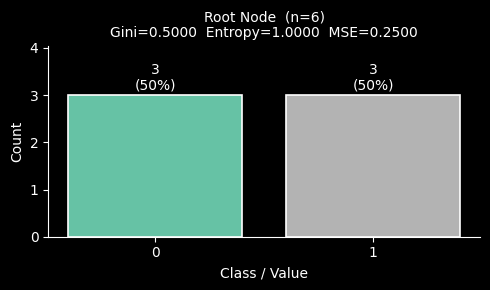


=== Best Split (metric=entropy) ===
  Parent impurity  = 1.000000  (n=6)
  Best threshold   = 2.5000
  Information gain = 0.459148
  Left  node: n=2,  entropy=-0.0000,  mean=1.0000
  Right node: n=4, entropy=0.8113,  mean=0.2500


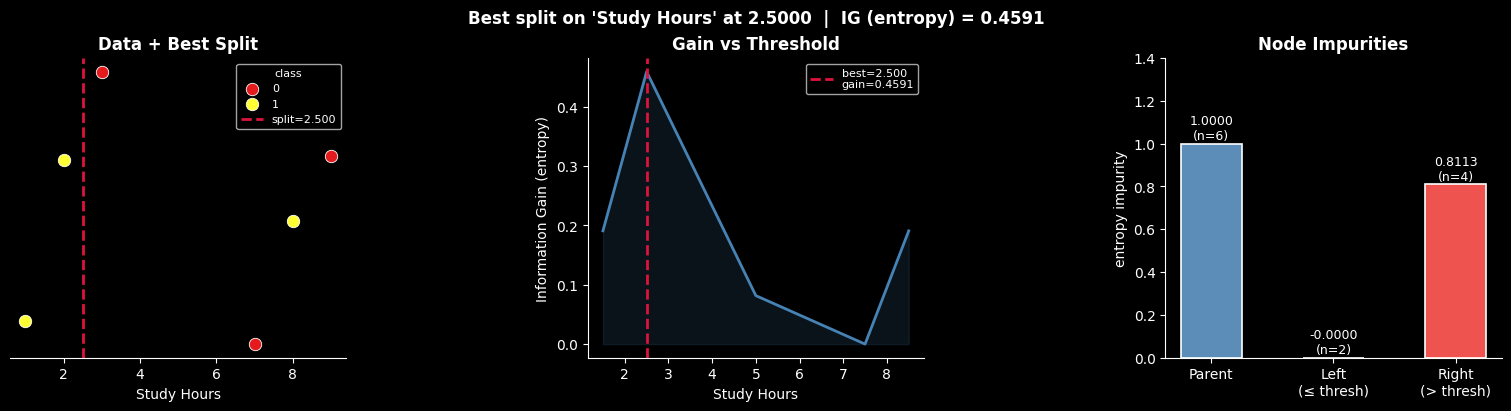

In [17]:
def gini(y):
    """Gini impurity of label array y."""
    y = np.array(y)
    _, counts = np.unique(y, return_counts=True)
    probs = counts / len(y)
    return 1 - np.sum(probs**2)

def entropy(y):
    """Entropy (bits) of label array y."""
    y = np.array(y)
    _, counts = np.unique(y, return_counts=True)
    probs = counts / len(y)
    return -np.sum([p * np.log2(p) for p in probs if p > 0])

def mse_impurity(y):
    """MSE impurity (variance) — used in regression trees."""
    y = np.array(y, dtype=float)
    return float(np.mean((y - np.mean(y))**2))

def weighted_impurity(y_left, y_right, metric="gini"):
    """Weighted impurity after a split. metric: 'gini'|'entropy'|'mse'"""
    fn = {"gini": gini, "entropy": entropy, "mse": mse_impurity}[metric]
    n = len(y_left) + len(y_right)
    return (len(y_left) / n) * fn(y_left) + (len(y_right) / n) * fn(y_right)

def information_gain(y_parent, y_left, y_right, metric="entropy"):
    """IG = impurity(parent) - weighted_impurity(children). metric: 'gini'|'entropy'|'mse'"""
    fn = {"gini": gini, "entropy": entropy, "mse": mse_impurity}[metric]
    return fn(y_parent) - weighted_impurity(y_left, y_right, metric)


def node_metrics(y, label="Node", plot=True):
    """
    Prints gini, entropy, mse for a node.
    If plot=True, draws a class-distribution bar chart for the node.

    Usage
    -----
    node_metrics(y, label="Root", plot=True)
    """
    import matplotlib.pyplot as plt

    y = np.array(y)
    print(f"\n=== {label} ===")
    print(f"  n        = {len(y)}")
    print(f"  Gini     = {gini(y):.6f}")
    print(f"  Entropy  = {entropy(y):.6f}")
    print(f"  MSE/Var  = {mse_impurity(y):.6f}")

    is_categorical = np.issubdtype(y.dtype, np.integer) or y.dtype == object
    vals, cnts = np.unique(y, return_counts=True)
    if is_categorical:
        for v, c in zip(vals, cnts):
            print(f"  class {v}: {c}/{len(y)} = {c/len(y):.4f}")
    else:
        print(f"  mean     = {np.mean(y):.4f}")

    if not plot:
        return

    fig, ax = plt.subplots(figsize=(5, 3))
    colors = plt.cm.Set2(np.linspace(0, 1, len(vals)))
    bars = ax.bar([str(v) for v in vals], cnts, color=colors, edgecolor="white", linewidth=1.2)
    for bar, cnt in zip(bars, cnts):
        ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.05,
                f"{cnt}\n({cnt/len(y):.0%})", ha="center", va="bottom", fontsize=10)

    ax.set_title(
        f"{label}  (n={len(y)})\n"
        f"Gini={gini(y):.4f}  Entropy={entropy(y):.4f}  MSE={mse_impurity(y):.4f}",
        fontsize=10
    )
    ax.set_xlabel("Class / Value"); ax.set_ylabel("Count")
    ax.set_ylim(0, max(cnts) * 1.35)
    ax.spines[["top","right"]].set_visible(False)
    plt.tight_layout()
    plt.show()


def find_best_split_1d(X, y, metric="mse",
                       feature_name="Feature", plot=True):
    """
    Brute-force best split for a 1-D feature array.
    Returns best_threshold, best_gain, (y_left, y_right).

    Parameters
    ----------
    X            : 1-D array of feature values
    y            : 1-D array of targets / labels
    metric       : 'gini' | 'entropy' | 'mse'
    feature_name : label shown on x-axis of plot
    plot         : if True, draw a 3-panel visualisation:
                     • scatter of data coloured by class/value
                     • impurity-gain curve over all candidate thresholds
                     • side-by-side node impurity bars (parent → left/right)

    Usage
    -----
    thresh, gain, (yl, yr) = find_best_split_1d(X, y, metric="entropy",
                                                 feature_name="Study Hours")
    """
    import matplotlib.pyplot as plt
    import matplotlib.gridspec as gridspec

    X = np.array(X, dtype=float)
    y = np.array(y)
    fn = {"gini": gini, "entropy": entropy, "mse": mse_impurity}[metric]

    sort_idx = np.argsort(X)
    X_s, y_s = X[sort_idx], y[sort_idx]

    best_thresh = None
    best_gain   = -np.inf
    best_left   = best_right = None

    parent_impurity = fn(y)
    all_thresholds, all_gains = [], []

    for i in range(len(X_s) - 1):
        thresh = (X_s[i] + X_s[i + 1]) / 2
        mask   = X <= thresh
        yl, yr = y[mask], y[~mask]
        if len(yl) == 0 or len(yr) == 0:
            continue
        gain = parent_impurity - weighted_impurity(yl, yr, metric)
        all_thresholds.append(thresh)
        all_gains.append(gain)
        if gain > best_gain:
            best_gain, best_thresh = gain, thresh
            best_left, best_right  = yl, yr

    # ── print summary ──────────────────────────────────────────
    print(f"\n=== Best Split (metric={metric}) ===")
    print(f"  Parent impurity  = {parent_impurity:.6f}  (n={len(y)})")
    print(f"  Best threshold   = {best_thresh:.4f}")
    print(f"  Information gain = {best_gain:.6f}")
    print(f"  Left  node: n={len(best_left)},  "
          f"{metric}={fn(best_left):.4f},  mean={np.mean(best_left):.4f}")
    print(f"  Right node: n={len(best_right)}, "
          f"{metric}={fn(best_right):.4f},  mean={np.mean(best_right):.4f}")

    if not plot:
        return best_thresh, best_gain, (best_left, best_right)

    # ── 3-panel figure ─────────────────────────────────────────
    is_categorical = np.issubdtype(y.dtype, np.integer) or y.dtype == object
    classes = np.unique(y)
    cmap    = plt.cm.Set1(np.linspace(0, 0.6, len(classes)))
    class_color = {c: cmap[i] for i, c in enumerate(classes)}

    fig = plt.figure(figsize=(15, 4), constrained_layout=True)
    gs  = gridspec.GridSpec(1, 3, figure=fig, wspace=0.38)

    # ── Panel 1: data scatter coloured by class ────────────────
    ax1 = fig.add_subplot(gs[0])
    for cls in classes:
        mask_c = y == cls
        ax1.scatter(X[mask_c],
                    np.zeros(mask_c.sum()) + np.random.uniform(-0.05, 0.05, mask_c.sum()),
                    color=class_color[cls], label=str(cls),
                    s=80, zorder=3, edgecolors="white", linewidths=0.6)
    ax1.axvline(best_thresh, color="crimson", lw=2, ls="--",
                label=f"split={best_thresh:.3f}")
    ax1.set_yticks([])
    ax1.set_xlabel(feature_name)
    ax1.set_title("Data + Best Split", fontweight="bold")
    ax1.legend(title="class", fontsize=8, title_fontsize=8)
    ax1.spines[["top","right","left"]].set_visible(False)

    # ── Panel 2: gain curve over all thresholds ────────────────
    ax2 = fig.add_subplot(gs[1])
    ax2.plot(all_thresholds, all_gains, color="steelblue", lw=2)
    ax2.axvline(best_thresh, color="crimson", lw=2, ls="--",
                label=f"best={best_thresh:.3f}\ngain={best_gain:.4f}")
    ax2.fill_between(all_thresholds, all_gains, alpha=0.15, color="steelblue")
    ax2.set_xlabel(feature_name)
    ax2.set_ylabel(f"Information Gain ({metric})")
    ax2.set_title("Gain vs Threshold", fontweight="bold")
    ax2.legend(fontsize=8)
    ax2.spines[["top","right"]].set_visible(False)

    # ── Panel 3: node impurity bars (parent / left / right) ────
    ax3 = fig.add_subplot(gs[2])
    node_labels  = ["Parent", "Left\n(≤ thresh)", "Right\n(> thresh)"]
    node_values  = [parent_impurity, fn(best_left), fn(best_right)]
    node_sizes   = [len(y), len(best_left), len(best_right)]
    bar_colors   = ["#5B8DB8", "#66BB6A", "#EF5350"]
    bars = ax3.bar(node_labels, node_values, color=bar_colors,
                   edgecolor="white", linewidth=1.2, width=0.5)
    for bar, val, sz in zip(bars, node_values, node_sizes):
        ax3.text(bar.get_x() + bar.get_width() / 2,
                 bar.get_height() + 0.005,
                 f"{val:.4f}\n(n={sz})",
                 ha="center", va="bottom", fontsize=9)
    ax3.set_ylabel(f"{metric} impurity")
    ax3.set_title("Node Impurities", fontweight="bold")
    ax3.set_ylim(0, max(node_values) * 1.4)
    ax3.spines[["top","right"]].set_visible(False)

    fig.suptitle(
        f"Best split on '{feature_name}' at {best_thresh:.4f}  |  "
        f"IG ({metric}) = {best_gain:.4f}",
        fontsize=12, fontweight="bold"
    )
    plt.show()

    return best_thresh, best_gain, (best_left, best_right)


# ─── EXAMPLE ──────────────────────────────────────────────────
if __name__ == "__main__":
    y_node = np.array([1, 1, 0, 0, 1, 0])
    node_metrics(y_node, label="Root Node", plot=True)

    X_feat = np.array([1, 2, 3, 7, 8, 9], dtype=float)
    find_best_split_1d(X_feat, y_node, metric="entropy",
                       feature_name="Study Hours", plot=True)

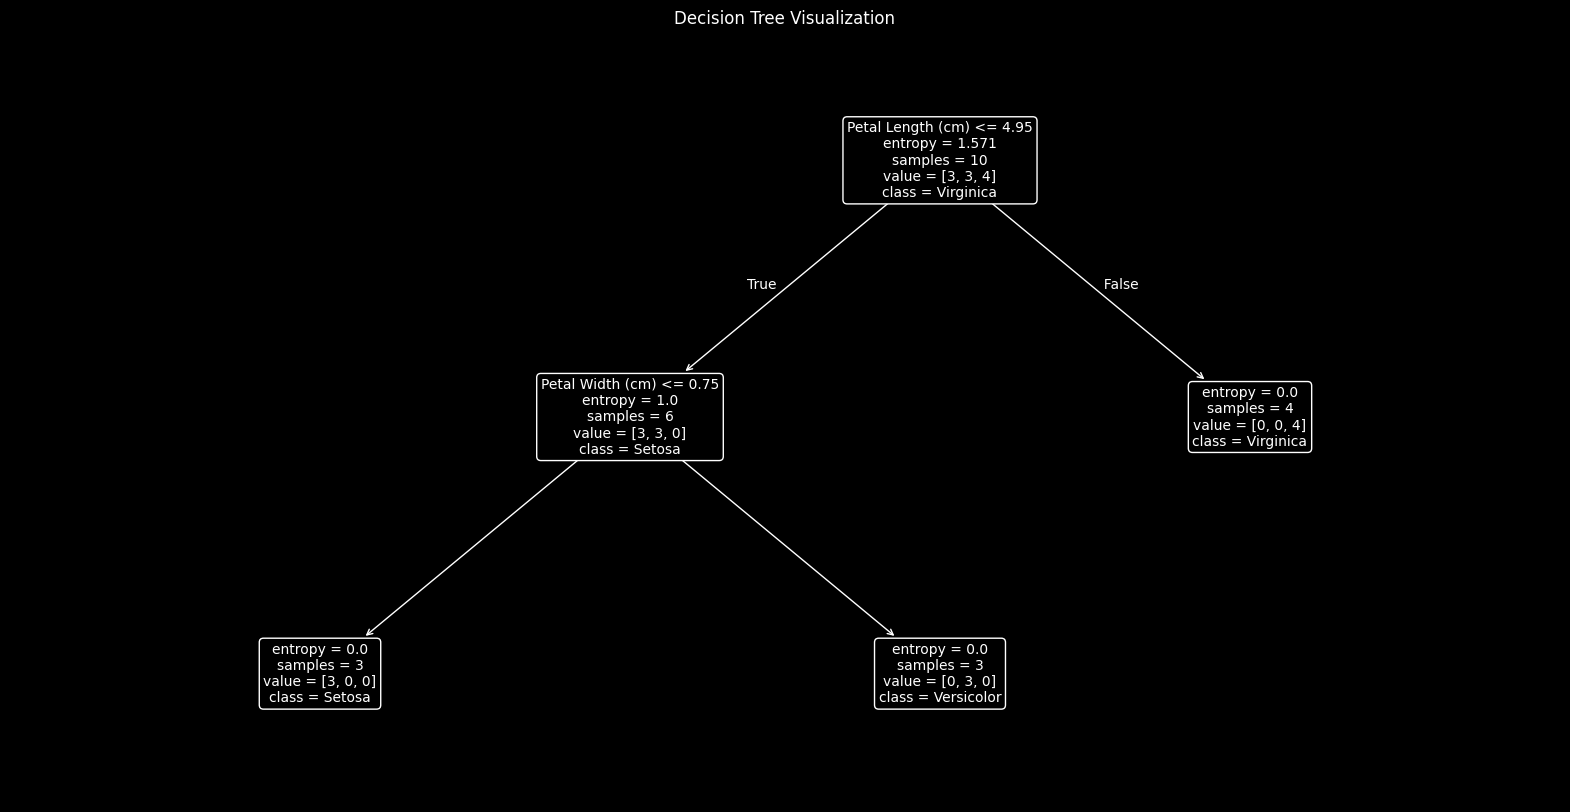

In [44]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.datasets import load_iris

def visualize_tree(X, y, feature_names=None, class_names=None, max_depth=None):
    """
    Fits a Decision Tree and plots it.

    Inputs:
    - X: Feature matrix (NumPy array or DataFrame)
    - y: Labels (NumPy array or Series)
    - feature_names: List of names for the columns in X
    - class_names: List of names for the unique values in y
    """

    # 1. Initialize and Fit the model
    # We use 'entropy' to match your image; you can also use 'gini'
    clf = DecisionTreeClassifier(criterion='entropy', max_depth=max_depth, random_state=42)
    clf.fit(X, y)

    # 2. Setup the visualization
    plt.figure(figsize=(20, 10))

    # 3. Plot the tree
    plot_tree(clf,
              feature_names=feature_names,
              class_names=class_names,
              filled=False,             # Colors nodes by class
              rounded=True,            # Makes boxes look like your image
              fontsize=10,
              precision=3)             # Number of decimal places for values

    plt.title("Decision Tree Visualization")
    plt.show()

# --- EXAMPLE USAGE ---
if __name__ == "__main__":
    # Load Iris data as a proxy for the data in your image
    #iris = load_iris()
    #X = iris.data
    #y = iris.target

    # Plug in your own data here:
    # Features: [Petal Length, Petal Width]
    X = np.array([
        [1.4, 0.2], [1.3, 0.2], [1.5, 0.2], [4.5, 1.3], [4.8, 1.4],
        [4.7, 1.3], [5.1, 1.9], [5.9, 2.1], [5.6, 2.0], [5.8, 2.2]])
    # Labels: 0=Setosa, 1=Versicolor, 2=Virginica
    y = np.array([0, 0, 0, 1, 1, 1, 2, 2, 2, 2])

    visualize_tree(
        X,
        y,
        feature_names=["Petal Length (cm)", "Petal Width (cm)"],
        class_names=["Setosa", "Versicolor", "Virginica"],
        max_depth=4 # You can increase this for a bigger tree
    )

## 16. K-Means Clustering

In [4]:
import numpy as np

def solve_kmeans():
    # --- 1. DATA ---
    # Change this to [[x1], [x2]...] for 1D or [[x1, y1], [x2, y2]...] for 2D
    X = np.array([
        [2,4],[2,6],[2,8],[8,4],[10,3],[10,5]
    ])

    # --- 2. INITIAL CENTERS ---
    # Must match the dimensions of X
    centers = np.array([
        [2,4], # c1
        [8,4],  # c2
    ])

    max_iter = 10
    print(f"Starting K-Means on {X.shape[1]}D data with {len(X)} points...")

    for i in range(max_iter):
        # Step A: Assignment
        distances = np.linalg.norm(X[:, np.newaxis] - centers, axis=2)
        labels = np.argmin(distances, axis=1)

        # Step B: Update Centers
        new_centers = np.array([X[labels == k].mean(axis=0) if np.any(labels == k)
                                else centers[k] for k in range(len(centers))])

        print(f"\n--- Iteration {i+1} ---")
        for k in range(len(centers)):
            mask = (labels == k)
            num_points = np.sum(mask)
            cluster_points = X[mask].tolist() # keeps the 2D structure

            # Format the center for clean printing
            center_display = [round(val, 2) for val in new_centers[k]]

            print(f"  Cluster {k+1}:")
            print(f"    Center: {center_display}")
            print(f"    Size:   {num_points} points")
            print(f"    Points: {cluster_points}")

        # Check for convergence
        if np.allclose(centers, new_centers):
            print("\nFinal Converged Centers reached.")
            break

        centers = new_centers

if __name__ == "__main__":
    solve_kmeans()

Starting K-Means on 2D data with 6 points...

--- Iteration 1 ---
  Cluster 1:
    Center: [np.float64(2.0), np.float64(6.0)]
    Size:   3 points
    Points: [[2, 4], [2, 6], [2, 8]]
  Cluster 2:
    Center: [np.float64(9.33), np.float64(4.0)]
    Size:   3 points
    Points: [[8, 4], [10, 3], [10, 5]]

--- Iteration 2 ---
  Cluster 1:
    Center: [np.float64(2.0), np.float64(6.0)]
    Size:   3 points
    Points: [[2, 4], [2, 6], [2, 8]]
  Cluster 2:
    Center: [np.float64(9.33), np.float64(4.0)]
    Size:   3 points
    Points: [[8, 4], [10, 3], [10, 5]]

Final Converged Centers reached.


In [11]:
import numpy as np

# --- 1. ACTIVATION FUNCTIONS ---
def relu(x):
    return np.maximum(0, x)

def sigmoid(x):
    return 1 / (1 + np.exp(-x))

def add_bias(X):
    """Prepends a column of ones to a matrix (the [1, f(...)] part)."""
    ones = np.ones((X.shape[0], 1))
    return np.hstack((ones, X))

# --- 2. QUESTION 3 TEMPLATE (Standard Layers) ---
def solve_question_3():
    print("--- Question 3 Output ---")
    # Plug in your matrices here
    X = np.array([[1, 1, 3.0],
                  [1, 2, 2.5]])

    W1 = np.array([[-1, 0, 1],
                   [ 0, -1, 0],
                   [ 1, 0, 1]])

    W2 = W1  # In this specific problem W1 = W2

    # Calculation: f( f(X*W1) * W2 )
    layer1 = relu(np.dot(X, W1))
    output = relu(np.dot(layer1, W2))

    print(np.round(output, 1))

# --- 3. QUESTION 4 TEMPLATE (With Bias Terms [1, ...]) ---
def solve_question_4():
    print("\n--- Question 4 Output ---")
    # Plug in your matrices here
    X = np.array([[1, 2, 1],
                  [1, 5, 1]])

    W1 = np.array([[-1, 0, 1],
                   [ 0, -1, 0],
                   [ 1, 0, -1]])

    W2 = np.array([[-1, 0, 1],
                   [ 0, -1, 0],
                   [ 1, 0, 1],
                   [ 1, -1, 1]])

    W3 = W2  # In this specific problem W2 = W3

    # Layer 1: f(X * W1)
    # Note: X doesn't have a bias [1] prepended in the image formula for the first step
    z1 = np.dot(X, W1)
    a1 = sigmoid(z1)

    # Layer 2: f([1, a1] * W2)
    a1_biased = add_bias(a1)
    z2 = np.dot(a1_biased, W2)
    a2 = sigmoid(z2)

    # Layer 3: f([1, a2] * W3)
    a2_biased = add_bias(a2)
    z3 = np.dot(a2_biased, W3)
    output = sigmoid(z3)

    print(np.round(output, 1))

if __name__ == "__main__":
    solve_question_3()
    solve_question_4()

--- Question 3 Output ---
[[2. 0. 6.]
 [2. 0. 5.]]

--- Question 4 Output ---
[[0.5 0.2 0.9]
 [0.5 0.2 0.9]]


## 18. Bias-Variance TradeOff

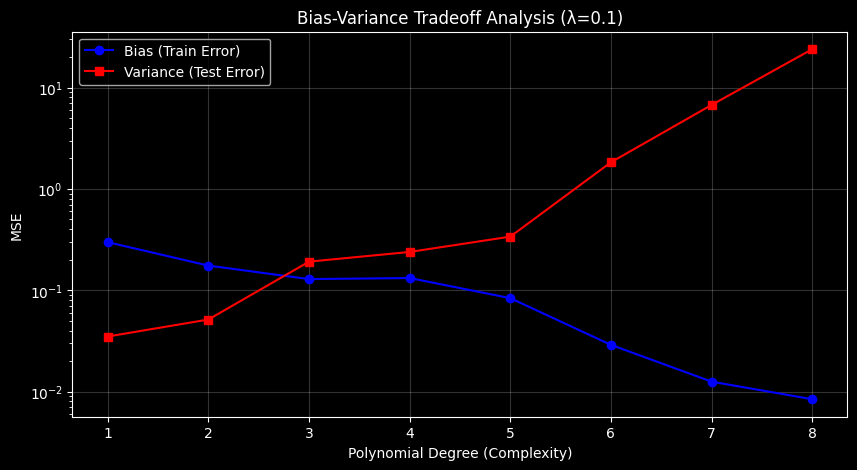

In [4]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import PolynomialFeatures
from sklearn.metrics import mean_squared_error

# ==========================================
# 1. USER SETTINGS: PLUG IN YOUR DATA HERE
# ==========================================
# Example: X is one feature (e.g., Square Footage), y is target (Price)
X_input = np.array([1, 2, 3, 4, 5, 6, 7, 8, 9, 10]).reshape(-1, 1)
y_input = np.array([1.2, 1.9, 3.2, 4.1, 5.1, 4.8, 7.2, 8.1, 9.5, 11.0])

# Split percentage (e.g., 0.8 means 80% training, 20% testing)
split_ratio = 0.8

# Tradeoff Parameters
lambda_to_test = 0.1    # Regularization strength (Lower = More Variance)
max_poly_degree = 8     # Max complexity to visualize

# ==========================================
# 2. THE ENGINE (Math Logic - Do Not Edit)
# ==========================================
def ridge_fit(X, y, lamb):
    m, d = X.shape
    if m >= d: # Primal Form
        return np.linalg.inv(X.T @ X + lamb * np.eye(d)) @ X.T @ y
    else:      # Dual Form
        return X.T @ np.linalg.inv(X @ X.T + lamb * np.eye(m)) @ y

def run_analysis():
    # Shuffle and Split
    indices = np.arange(len(X_input))
    np.random.shuffle(indices)
    split_idx = int(len(X_input) * split_ratio)

    train_idx, test_idx = indices[:split_idx], indices[split_idx:]
    X_train, y_train = X_input[train_idx], y_input[train_idx]
    X_test, y_test = X_input[test_idx], y_input[test_idx]

    train_errors, test_errors = [], []
    degrees = range(1, max_poly_degree + 1)

    for deg in degrees:
        # Polynomial Expansion
        poly = PolynomialFeatures(degree=deg)
        P_train = poly.fit_transform(X_train)
        P_test = poly.transform(X_test)

        # Fit using Primal/Dual Logic
        w = ridge_fit(P_train, y_train, lambda_to_test)

        # Score
        train_errors.append(mean_squared_error(y_train, P_train @ w))
        test_errors.append(mean_squared_error(y_test, P_test @ w))

    # Output Results
    plt.figure(figsize=(10, 5))
    plt.plot(degrees, train_errors, 'b-o', label='Bias (Train Error)')
    plt.plot(degrees, test_errors, 'r-s', label='Variance (Test Error)')
    plt.xlabel('Polynomial Degree (Complexity)')
    plt.ylabel('MSE')
    plt.yscale('log')
    plt.legend()
    plt.title(f'Bias-Variance Tradeoff Analysis (λ={lambda_to_test})')
    plt.grid(True, alpha=0.2)
    plt.show()

if __name__ == "__main__":
    run_analysis()